In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os

In [2]:
# Helper functions for converting gate duration into duration-anharmonicity product
qb_anh_rads = 212.3e6 * (2 * np.pi) #anharmonicity in rad/s
def tg2prod(tg):
    return tg * (qb_anh_rads*1e-9) / (2*np.pi) #Convert anh to GHz since time on axis is in ns


def prod2tg(prod):
    return prod * (2*np.pi) / (qb_anh_rads*1e-9) #Convert anh to GHz since time on axis is in ns

# Gate error vs duration

(4.5, 20.0)

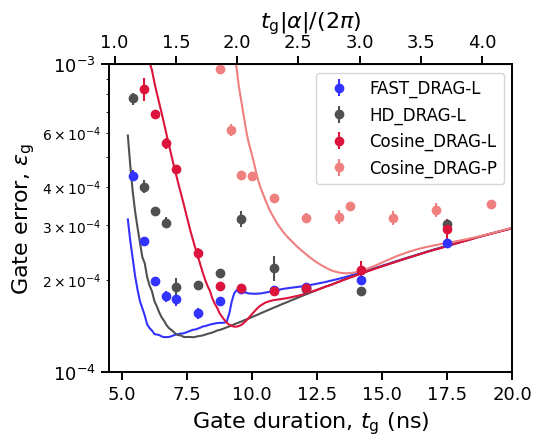

In [3]:
#Re-read csv-files and plot
pulse_names = ['FAST_DRAG-L', 'HD_DRAG-L', 'Cosine_DRAG-L', 'Cosine_DRAG-P']
dark_blue = [51/255,51/255,255/255] #[65,105,225]/255; %royal blue
crimson = [220/255, 20/255, 60/255] 
light_red = [240/255,128/255,128/255]
dark_gray = [80/255, 80/255, 80/255] #[64/255, 64/255, 64/255]

colors_dict = {'FAST_DRAG-L': dark_blue, 
               'Cosine_DRAG-L': crimson,'Cosine_DRAG-P': light_red,
               'HD_DRAG-L': dark_gray, 
    }


fig, ax = plt.subplots(1, 1, figsize=(5.2,4))
for pulse in pulse_names:
    #Experiments
    gate_error_arr = np.genfromtxt(os.path.join(pulse, 'gate_error_exp_arr.csv'), delimiter=',')
    gate_error_uncertainty_arr = np.genfromtxt(os.path.join(pulse, 'gate_error_exp_uncertainty_arr.csv'), delimiter=',')
    duration_arr = np.genfromtxt(os.path.join(pulse, 'duration_exp_arr.csv'), delimiter=',')
    plt.errorbar(duration_arr*1e9, gate_error_arr, yerr=gate_error_uncertainty_arr, fmt='o', color=colors_dict[pulse], label = '%s'%(pulse))
    #print(pulse, 'Minimum error %.4e at tg=%.3f ns'%(np.min(gate_error_arr), 1e9*duration_arr[np.argmin(gate_error_arr)]))
    #simulations
    gate_error_sim_arr = np.genfromtxt(os.path.join(pulse, 'gate_error_sim_arr.csv'), delimiter=',')
    duration_sim_arr = np.genfromtxt(os.path.join(pulse, 'duration_sim_arr.csv'), delimiter=',')
    plt.plot(duration_sim_arr*1e9, gate_error_sim_arr, '-', color=colors_dict[pulse])
    
plt.xlabel('Gate duration, $t_\mathrm{g}$ (ns)', fontsize = 16)
plt.ylabel(r'Gate error, $\varepsilon_\mathrm{g}$', fontsize = 16)
plt.legend(fontsize = 12, loc = 'upper right') #'upper right')
secax = ax.secondary_xaxis('top', functions=(tg2prod, prod2tg))
secax.set_xlabel(r'$t_\mathrm{g}|\alpha|/(2\pi)$', fontsize=16)
ax.set_yscale("log")
ax.tick_params(length=6, width = 1.4, labelsize=13)
secax.tick_params(length=6, width = 1.4, labelsize=13)
ax.tick_params(length=6, width = 1.4)
for side in ['top', 'left', 'right', 'bottom']:
    ax.spines[side].set_linewidth(1.4)
plt.ylim([1e-4, 10e-4])
plt.xlim([4.5, 20])

# T1 vs duration

 Note that T1 and T2 echo were measured after gate calibration for each pulse duration to observe if there are any time-dependent fluctuations of coherence that could affect the measured gate error as a function of gate duration. 


(4.5, 20.0)

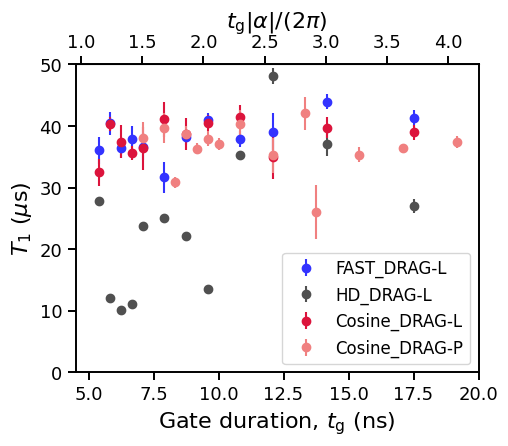

In [4]:
fig, ax = plt.subplots(1, 1, figsize=(5.2,4))
for pulse in pulse_names:
    #Experiments
    T1_mean_arr = np.genfromtxt(os.path.join(pulse, 'T1_mean_exp_arr.csv'), delimiter=',')
    T1_uncertainty_arr = np.genfromtxt(os.path.join(pulse, 'T1_uncertainty_exp_arr.csv'), delimiter=',')
    duration_arr = np.genfromtxt(os.path.join(pulse, 'duration_exp_arr.csv'), delimiter=',')
    plt.errorbar(duration_arr*1e9, T1_mean_arr*1e6, yerr=T1_uncertainty_arr*1e6, fmt='o', color=colors_dict[pulse], label = '%s'%(pulse))

    
plt.xlabel('Gate duration, $t_\mathrm{g}$ (ns)', fontsize = 16)
plt.ylabel(r'$T_1$ ($\mu$s)', fontsize = 16)
plt.legend(fontsize = 12, loc = 'lower right') #'upper right')
secax = ax.secondary_xaxis('top', functions=(tg2prod, prod2tg))
secax.set_xlabel(r'$t_\mathrm{g}|\alpha|/(2\pi)$', fontsize=16)
ax.tick_params(length=6, width = 1.4, labelsize=13)
secax.tick_params(length=6, width = 1.4, labelsize=13)
ax.tick_params(length=6, width = 1.4)
for side in ['top', 'left', 'right', 'bottom']:
    ax.spines[side].set_linewidth(1.4)
plt.ylim([0, 50])
plt.xlim([4.5, 20])

# T2 echo vs duration

(4.5, 20.0)

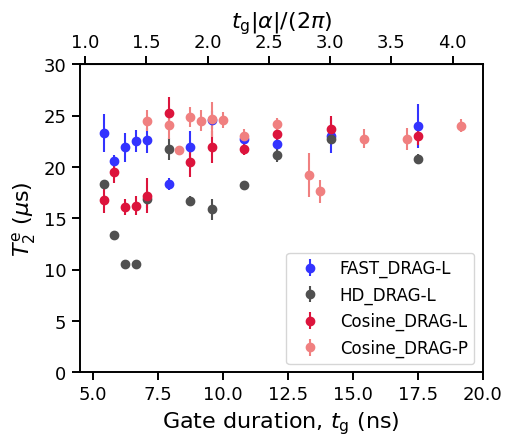

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(5.2,4))
for pulse in pulse_names:
    #Experiments
    T2Echo_mean_arr = np.genfromtxt(os.path.join(pulse, 'T2Echo_mean_exp_arr.csv'), delimiter=',')
    T2Echo_uncertainty_arr = np.genfromtxt(os.path.join(pulse, 'T2Echo_uncertainty_exp_arr.csv'), delimiter=',')
    duration_arr = np.genfromtxt(os.path.join(pulse, 'duration_exp_arr.csv'), delimiter=',')
    plt.errorbar(duration_arr*1e9, T2Echo_mean_arr*1e6, yerr=T2Echo_uncertainty_arr*1e6, fmt='o', color=colors_dict[pulse], label = '%s'%(pulse))

    
plt.xlabel('Gate duration, $t_\mathrm{g}$ (ns)', fontsize = 16)
plt.ylabel(r'$T_2^\mathrm{e}$ ($\mu$s)', fontsize = 16)
plt.legend(fontsize = 12, loc = 'lower right') #'upper right')
secax = ax.secondary_xaxis('top', functions=(tg2prod, prod2tg))
secax.set_xlabel(r'$t_\mathrm{g}|\alpha|/(2\pi)$', fontsize=16)
ax.tick_params(length=6, width = 1.4, labelsize=13)
secax.tick_params(length=6, width = 1.4, labelsize=13)
ax.tick_params(length=6, width = 1.4)
for side in ['top', 'left', 'right', 'bottom']:
    ax.spines[side].set_linewidth(1.4)
plt.ylim([0, 30])
plt.xlim([4.5, 20])